In [38]:
import pandas as pd

df_labels = pd.read_csv("dataset_labels.csv")
df_labels

,file_path,filename,is_doc_id,id_doc_type,doc_type
0,dataset/false_doc,12031810-405818722.jpg,False,NaN,NaN
1,dataset/false_doc,facture-d-avoir-exemple-744x1024-2687424784.jpg,False,NaN,NaN
2,dataset/false_id,1-18900169.jpg,False,NaN,NaN
3,dataset/false_id,1-842369233.jpg,False,NaN,NaN
4,dataset/false_id,Document-d-identite-2.jpg,False,NaN,NaN
5,dataset/false_id,ID_passport_USA-2021-497107151.jpg,False,NaN,NaN
6,dataset/false_id,IMG_6211_LegalPhoto-1697863245.jpg,False,NaN,NaN
7,dataset/false_id,carte-d-identite-ce-qui-change-en-bretagne_317...,False,NaN,NaN
8,dataset/false_id,csm_CA_RPC_2021_1920_4c0a2d9287-515808575.jpg,False,NaN,NaN
9,dataset/false_id,les-faux-papiers-ne-sont-pas-toujours-facileme...,False,NaN,NaN


In [ ]:
df_results = pd.read_csv("results.csv", sep=";")
df_results

[skip] Azure CU: not enough data (n=0)


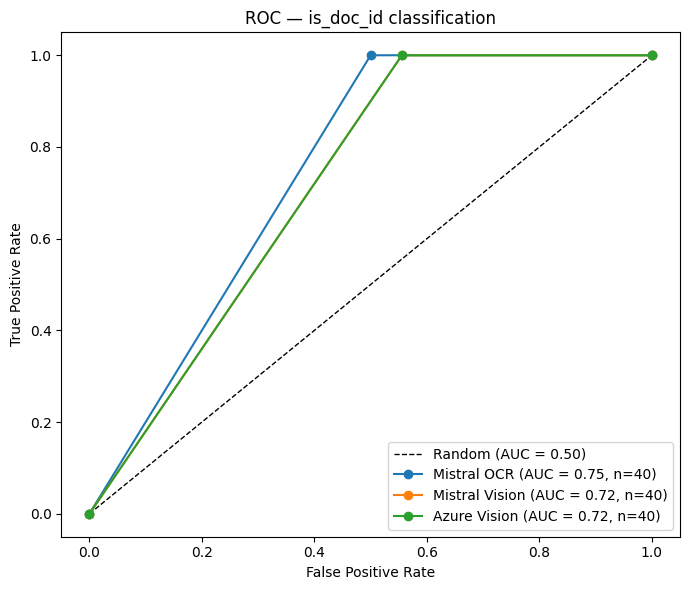

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

MODELS = {
    "Mistral OCR":    "mistral_is_doc_id",
    "Azure CU":       "azure_is_doc_id",
    "Mistral Vision": "mistral_vision_is_doc_id",
    "Azure Vision":   "azure_vision_is_doc_id",
}
BOOL_MAP = {True: 1, False: 0, "True": 1, "False": 0}

# Merge ground truth with model results on filename
merged = df_labels[["filename", "is_doc_id"]].merge(df_results, on="filename", suffixes=("_gt", ""))
merged = merged.dropna(subset=["is_doc_id"])


def get_yt_ys(col):
    """Return (y_true, y_score) for a given model column, excluding missing predictions."""
    mask = merged[col].notna() & (merged[col] != "")
    y_t = merged.loc[mask, "is_doc_id"].astype(bool).astype(int)
    y_s = merged.loc[mask, col].map(BOOL_MAP).fillna(0).astype(int)
    return y_t, y_s


fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.50)")

for name, col in MODELS.items():
    y_t, y_s = get_yt_ys(col)
    if len(y_t) == 0 or y_t.nunique() < 2:
        print(f"[skip] {name}: not enough data (n={len(y_t)})")
        continue
    auc = roc_auc_score(y_t, y_s)
    fpr, tpr, _ = roc_curve(y_t, y_s)
    ax.plot(fpr, tpr, marker="o", label=f"{name} (AUC = {auc:.2f}, n={len(y_t)})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — is_doc_id classification")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score

rows = []
for name, col in MODELS.items():
    y_t, y_s = get_yt_ys(col)
    if len(y_t) == 0 or y_t.nunique() < 2:
        continue
    rows.append({
        "model":     name,
        "n":         len(y_t),
        "accuracy":  accuracy_score(y_t, y_s),
        "precision": precision_score(y_t, y_s, zero_division=0),
        "recall":    recall_score(y_t, y_s, zero_division=0),
        "f1":        f1_score(y_t, y_s, zero_division=0),
        "mcc":       matthews_corrcoef(y_t, y_s),
        "auc":       roc_auc_score(y_t, y_s),
    })

(pd.DataFrame(rows)
   .set_index("model")
   .style
   .format("{:.2f}", subset=["accuracy", "precision", "recall", "f1", "mcc", "auc"])
   .background_gradient(cmap="RdYlGn", subset=["accuracy", "precision", "recall", "f1", "mcc", "auc"])
)

,n,accuracy,precision,recall,f1,mcc,auc
model,,,,,,,
Mistral OCR,40,0.78,0.71,1.00,0.83,0.60,0.75
Mistral Vision,40,0.75,0.69,1.00,0.81,0.55,0.72
Azure Vision,40,0.75,0.69,1.00,0.81,0.55,0.72


## Conclusion — Performance des modèles sur `is_doc_id`

L'analyse porte sur **40 fichiers** labellisés (22 documents d'identité, 18 non-identité), évalués sur trois modèles disposant de résultats complets. Azure CU n'a produit aucune prédiction et est exclu.

### Résultats

| Modèle | Accuracy | Precision | Recall | F1 | MCC | AUC |
|---|---|---|---|---|---|---|
| **Mistral OCR** | **0.78** | **0.71** | **1.00** | **0.83** | **0.60** | **0.75** |
| Mistral Vision | 0.75 | 0.69 | 1.00 | 0.81 | 0.55 | 0.72 |
| Azure Vision | 0.75 | 0.69 | 1.00 | 0.81 | 0.55 | 0.72 |

### Points clés

**Recall parfait (1.00) sur les trois modèles** — aucun document d'identité réel n'est manqué. C'est la propriété la plus critique en vérification documentaire : un faux négatif (document d'identité non détecté) représente un risque métier majeur.

**Mistral OCR est le meilleur modèle** avec un F1 de 0.83 et un MCC de 0.60, devant Mistral Vision et Azure Vision à égalité (F1 = 0.81, MCC = 0.55). L'écart reste faible, ce qui suggère que l'OCR n'apporte pas d'avantage décisif sur la vision pure pour cette tâche de classification.

**Precision modérée (~0.69–0.71)** — entre 9 et 10 faux positifs sur 40 fichiers. Ces erreurs proviennent exclusivement de la catégorie `false_id` : photos de documents trouvées sur Internet, que les modèles interprètent comme de vrais documents d'identité. Cette catégorie est intrinsèquement ambiguë.

**Aucun faux négatif** — tous les vrais documents (cartes d'identité, passeports) sont correctement détectés par les trois modèles.

**MCC entre 0.55 et 0.60** — performance correcte mais en deçà du seuil recommandé pour la production (> 0.80). Le MCC est ici plus pertinent que l'accuracy car le dataset reste petit et légèrement déséquilibré.

### Limites de l'analyse

- **Dataset petit** (n=40 avec labels) — les métriques sont sensibles à 1 ou 2 exemples.
- **Azure CU non évalué** — absence de résultats dans `results.csv`, à relancer.
- **Catégorie `false_id` ambiguë** — images de documents issues du web : la tâche est plus difficile que des cas terrain réels où les faux documents ont un aspect différent.

### Recommandations

1. **Étendre le dataset** avec plus de cas négatifs réels (factures, relevés bancaires) pour réduire le taux de faux positifs.
2. **Relancer Azure CU** pour obtenir une comparaison complète sur les 4 modèles.
3. **Exploiter `id_doc_type`** comme filtre secondaire : un document classifié `is_doc_id=True` mais `id_doc_type=proof_of_residency` peut être traité différemment d'un passeport ou d'une carte d'identité.